# Satellite Classification: Diagnostics, Model Comparison & Robustness

Cleaned and reproducible portfolio version of a university machine-learning laboratory assignment.

**Reproducibility choices:** fixed random seeds, train-only preprocessing/feature selection, held-out evaluation, and explicit dataset paths.

## 0. Setup and data validation

The Landsat dataset contains 36 spectral features derived from a 3×3 pixel neighbourhood and one class label. The official train/test split is preserved throughout the main comparisons.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, roc_auc_score,
)

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42


def find_project_root():
    here = Path.cwd().resolve()
    for candidate in [here, here.parent, here.parent.parent]:
        if (candidate / "data" / "satellite_train.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find satellite data files.")

ROOT = find_project_root()
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

train_df = pd.read_csv(DATA_DIR / "satellite_train.csv")
test_df = pd.read_csv(DATA_DIR / "satellite_test.csv")

X_train = train_df.iloc[:, :-1]
y_train = train_df.iloc[:, -1]
X_test = test_df.iloc[:, :-1]
y_test = test_df.iloc[:, -1]

assert train_df.isna().sum().sum() == 0
assert test_df.isna().sum().sum() == 0
print("Train:", X_train.shape, y_train.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Classes:", sorted(y_train.unique()))

Train: (4435, 36) (4435,)
Test:  (2000, 36) (2000,)
Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7)]


## 1. Spatial-spectral correlation diagnostics

Strong correlation is expected because neighbouring pixels and spectral bands contain overlapping information. This matters especially for covariance-based classifiers such as LDA and QDA.

Median absolute off-diagonal correlation: 0.359
90th percentile absolute correlation: 0.906


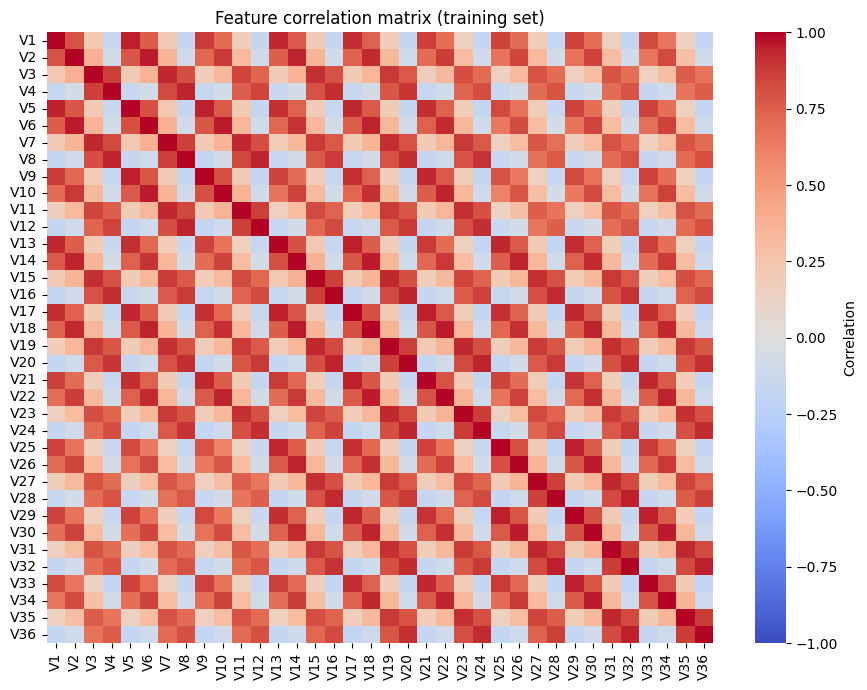

In [2]:
corr = X_train.corr()
mask = ~np.eye(corr.shape[0], dtype=bool)
off_diag = corr.to_numpy()[mask]
print("Median absolute off-diagonal correlation:", round(np.median(np.abs(off_diag)), 3))
print("90th percentile absolute correlation:", round(np.quantile(np.abs(off_diag), 0.90), 3))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, vmin=-1, vmax=1, center=0, cmap="coolwarm", cbar_kws={"label": "Correlation"})
plt.title("Feature correlation matrix (training set)")
plt.tight_layout()
plt.savefig(FIG_DIR / "satellite_correlation_heatmap.png", dpi=160)
plt.show()

## 2. Where do LDA assumptions fit — and where do they crack?

LDA assumes a shared covariance matrix across classes. We inspect three feature pairs and compare class-specific covariance matrices. Large differences in covariance structure weaken the shared-covariance assumption.

,feature_pair,average_covariance_distance
0,V1 vs V2,79.246997
2,V5 vs V20,112.479576
1,V10 vs V11,132.036891


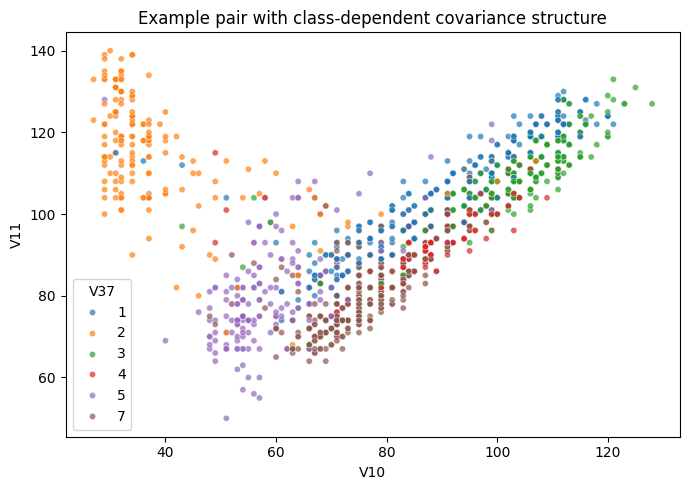

In [3]:
pairs = [("V1", "V2"), ("V10", "V11"), ("V5", "V20")]
rows = []
for f1, f2 in pairs:
    covs = {}
    for cls in sorted(y_train.unique()):
        subset = X_train.loc[y_train == cls, [f1, f2]].to_numpy()
        covs[cls] = np.cov(subset, rowvar=False)
    matrices = list(covs.values())
    mean_cov = np.mean(matrices, axis=0)
    avg_distance = np.mean([np.linalg.norm(cov - mean_cov, ord="fro") for cov in matrices])
    rows.append({"feature_pair": f"{f1} vs {f2}", "average_covariance_distance": avg_distance})

covariance_diagnostics = pd.DataFrame(rows).sort_values("average_covariance_distance")
display(covariance_diagnostics)

sample = train_df.sample(n=min(1800, len(train_df)), random_state=RANDOM_STATE)
plt.figure(figsize=(7, 5))
sns.scatterplot(data=sample, x="V10", y="V11", hue="V37", palette="tab10", s=20, alpha=0.7)
plt.title("Example pair with class-dependent covariance structure")
plt.tight_layout()
plt.savefig(FIG_DIR / "lda_assumption_example.png", dpi=160)
plt.show()

## 3. Probability threshold vs. ROC/AUC

For classes 1 vs 7, the training data is split into fit/validation subsets. Thresholds are selected **only on validation data**, then evaluated on the untouched official test set. This avoids tuning the threshold on the test set.

Validation-selected Youden threshold: 0.05
Validation-selected F1 threshold:     0.05
Official test ROC AUC:                1.000


,threshold_rule,threshold,accuracy,precision,recall,f1
0,Youden,0.05,0.992481,0.985043,1.0,0.992465
1,F1,0.05,0.992481,0.985043,1.0,0.992465
2,Default 0.5,0.50,0.996778,0.993534,1.0,0.996757


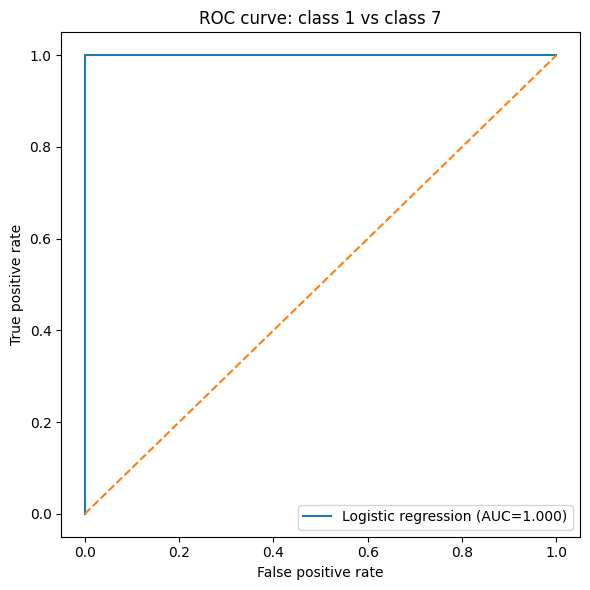

In [4]:
classes = [1, 7]
train_mask = y_train.isin(classes)
test_mask = y_test.isin(classes)

X_binary = X_train.loc[train_mask]
y_binary = (y_train.loc[train_mask] == 1).astype(int)
X_binary_test = X_test.loc[test_mask]
y_binary_test = (y_test.loc[test_mask] == 1).astype(int)

X_fit, X_val, y_fit, y_val = train_test_split(
    X_binary, y_binary, test_size=0.25, random_state=RANDOM_STATE, stratify=y_binary
)

binary_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])
binary_model.fit(X_fit, y_fit)
val_prob = binary_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)
validation_rows = []
for threshold in thresholds:
    pred = (val_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    recall = tp / (tp + fn)
    specificity = tn / (tn + fp)
    validation_rows.append({
        "threshold": threshold,
        "youden_j": recall + specificity - 1,
        "f1": f1_score(y_val, pred),
    })
threshold_df = pd.DataFrame(validation_rows)
youden_threshold = threshold_df.loc[threshold_df["youden_j"].idxmax(), "threshold"]
f1_threshold = threshold_df.loc[threshold_df["f1"].idxmax(), "threshold"]

prob_test = binary_model.predict_proba(X_binary_test)[:, 1]
auc_test = roc_auc_score(y_binary_test, prob_test)
print(f"Validation-selected Youden threshold: {youden_threshold:.2f}")
print(f"Validation-selected F1 threshold:     {f1_threshold:.2f}")
print(f"Official test ROC AUC:                {auc_test:.3f}")

metric_rows = []
for label, threshold in [("Youden", youden_threshold), ("F1", f1_threshold), ("Default 0.5", 0.5)]:
    pred = (prob_test >= threshold).astype(int)
    metric_rows.append({
        "threshold_rule": label,
        "threshold": threshold,
        "accuracy": accuracy_score(y_binary_test, pred),
        "precision": precision_score(y_binary_test, pred),
        "recall": recall_score(y_binary_test, pred),
        "f1": f1_score(y_binary_test, pred),
    })
display(pd.DataFrame(metric_rows))

fpr, tpr, _ = roc_curve(y_binary_test, prob_test)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Logistic regression (AUC={auc_test:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve: class 1 vs class 7")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "satellite_roc_curve.png", dpi=160)
plt.show()

## 4. Feature reduction: do fewer features lead to better decisions?

Feature selection/transformation is fitted **only on the training set**, and every strategy is evaluated on the official test set. We compare all 36 features, top-20 mutual-information features, and 20 PCA components.

,strategy,model,accuracy,macro_f1
5,Mutual information (20),QDA,0.8495,0.804662
8,PCA (20),QDA,0.8540,0.804055
2,All 36 features,QDA,0.8530,0.801293
6,PCA (20),LogReg,0.8400,0.799726
0,All 36 features,LogReg,0.8395,0.797053
3,Mutual information (20),LogReg,0.8340,0.792092
1,All 36 features,LDA,0.8285,0.785836
7,PCA (20),LDA,0.8250,0.781168
4,Mutual information (20),LDA,0.8185,0.773638


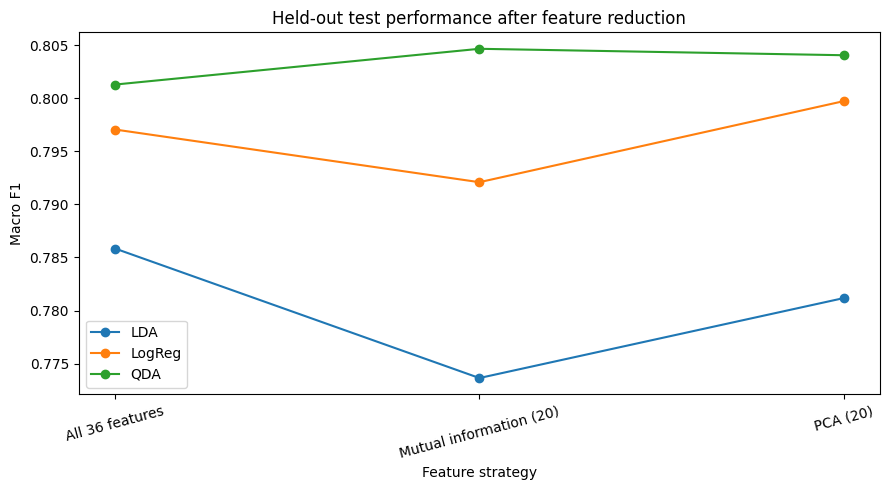

In [5]:
def mutual_info_seeded(X, y):
    return mutual_info_classif(X, y, random_state=RANDOM_STATE)

strategies = {
    "All 36 features": [("scaler", StandardScaler())],
    "Mutual information (20)": [
        ("select", SelectKBest(mutual_info_seeded, k=20)),
        ("scaler", StandardScaler()),
    ],
    "PCA (20)": [
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=20, random_state=RANDOM_STATE)),
    ],
}

models = {
    "LogReg": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "LDA": LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
}

feature_rows = []
for strategy_name, steps in strategies.items():
    for model_name, model in models.items():
        pipeline = Pipeline(steps + [("model", clone(model))])
        pipeline.fit(X_train, y_train)
        pred = pipeline.predict(X_test)
        feature_rows.append({
            "strategy": strategy_name,
            "model": model_name,
            "accuracy": accuracy_score(y_test, pred),
            "macro_f1": f1_score(y_test, pred, average="macro"),
        })

feature_results = pd.DataFrame(feature_rows)
display(feature_results.sort_values(["macro_f1", "accuracy"], ascending=False))

pivot = feature_results.pivot(index="strategy", columns="model", values="macro_f1")
plt.figure(figsize=(9, 5))
for model_name in pivot.columns:
    plt.plot(pivot.index, pivot[model_name], marker="o", label=model_name)
plt.ylabel("Macro F1")
plt.xlabel("Feature strategy")
plt.title("Held-out test performance after feature reduction")
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_reduction_comparison.png", dpi=160)
plt.show()

**Interpretation.** Reducing to 20 features/components does not clearly improve performance. PCA keeps performance close to the full-feature baseline, while mutual-information selection is competitive for QDA but slightly worse for linear models.

## 5. QDA vs. quadratic logistic regression

Quadratic logistic regression is implemented as standardized second-degree polynomial features followed by regularized multinomial logistic regression. Both models are trained on the official training set and evaluated on the official test set.

,model,accuracy,macro_f1,macro_precision,macro_recall
0,Quadratic logistic,0.8875,0.871861,0.876276,0.868341
1,QDA,0.8530,0.801293,0.844272,0.803745


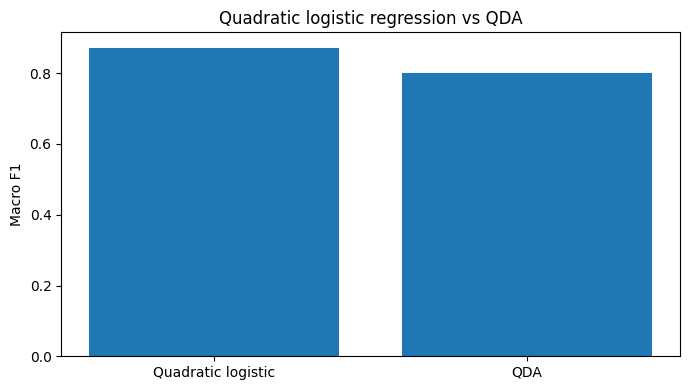

In [6]:
quadratic_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("logreg", LogisticRegression(max_iter=5000, C=0.5, random_state=RANDOM_STATE)),
])
qda_model = Pipeline([
    ("scaler", StandardScaler()),
    ("qda", QuadraticDiscriminantAnalysis(reg_param=0.1)),
])

comparison_rows = []
for name, model in [("Quadratic logistic", quadratic_logreg), ("QDA", qda_model)]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    comparison_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "macro_precision": precision_score(y_test, pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_test, pred, average="macro", zero_division=0),
    })
model_comparison = pd.DataFrame(comparison_rows)
display(model_comparison)

plt.figure(figsize=(7, 4))
plt.bar(model_comparison["model"], model_comparison["macro_f1"])
plt.ylabel("Macro F1")
plt.title("Quadratic logistic regression vs QDA")
plt.tight_layout()
plt.savefig(FIG_DIR / "quadratic_logistic_vs_qda.png", dpi=160)
plt.show()

## 6. Small-sample regime sensitivity

Each model is trained on stratified subsets of the official training data. Results are averaged across three deterministic repetitions per fraction. The official test set remains fixed.

,fraction,model,train_accuracy,test_accuracy
21,0.8,LDA,0.847332,0.829833
22,0.8,LogReg,0.875986,0.836833
23,0.8,QDA,0.871289,0.850667
24,0.9,LDA,0.845402,0.831500
25,0.9,LogReg,0.874133,0.836833
26,0.9,QDA,0.869373,0.848833
27,1.0,LDA,0.843292,0.830500
28,1.0,LogReg,0.875761,0.839500
29,1.0,QDA,0.868095,0.848500


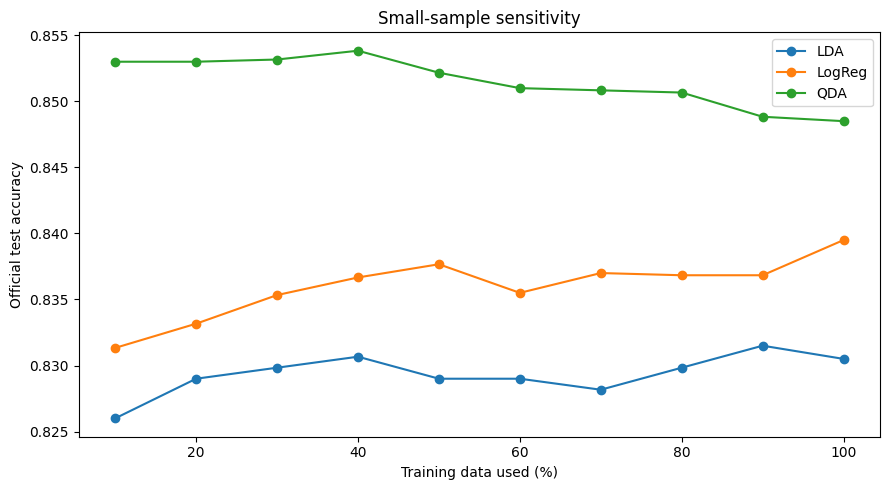

In [7]:
small_sample_models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    "LDA": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis(solver="lsqr", shrinkage=0.3)),
    ]),
    "QDA": Pipeline([
        ("scaler", StandardScaler()),
        ("model", QuadraticDiscriminantAnalysis(reg_param=0.5)),
    ]),
}

fractions = np.linspace(0.1, 1.0, 10)
learning_rows = []
for fraction in fractions:
    for repetition in range(3):
        if fraction < 1.0:
            X_subset, _, y_subset, _ = train_test_split(
                X_train, y_train,
                train_size=fraction,
                random_state=RANDOM_STATE + repetition,
                stratify=y_train,
            )
        else:
            X_subset, y_subset = X_train, y_train
        for model_name, model in small_sample_models.items():
            fitted = clone(model).fit(X_subset, y_subset)
            train_pred = fitted.predict(X_subset)
            test_pred = fitted.predict(X_test)
            learning_rows.append({
                "fraction": fraction,
                "model": model_name,
                "train_accuracy": accuracy_score(y_subset, train_pred),
                "test_accuracy": accuracy_score(y_test, test_pred),
            })

learning_df = pd.DataFrame(learning_rows)
learning_summary = learning_df.groupby(["fraction", "model"], as_index=False).mean(numeric_only=True)
display(learning_summary.tail(9))

plt.figure(figsize=(9, 5))
for model_name in learning_summary["model"].unique():
    subset = learning_summary[learning_summary["model"] == model_name]
    plt.plot(subset["fraction"] * 100, subset["test_accuracy"], marker="o", label=model_name)
plt.xlabel("Training data used (%)")
plt.ylabel("Official test accuracy")
plt.title("Small-sample sensitivity")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "small_sample_sensitivity.png", dpi=160)
plt.show()

## 7. Robustness to sensor quirks

Models are trained on clean training data, then evaluated on clean and perturbed test data. The simulated gain shift affects every fourth feature (one corresponding spectral position in each 4-value pixel group), while quantization rounds the same features to a coarser grid.

,model,perturbation,accuracy,macro_f1
0,LogReg,Clean,0.8395,0.797053
1,LogReg,Gain +10%,0.7725,0.689312
2,LogReg,Quantized,0.8375,0.800684
3,LDA,Clean,0.8260,0.782745
4,LDA,Gain +10%,0.7115,0.671636
5,LDA,Quantized,0.8300,0.791205
6,QDA,Clean,0.8535,0.810409
7,QDA,Gain +10%,0.8255,0.794908
8,QDA,Quantized,0.8570,0.818034


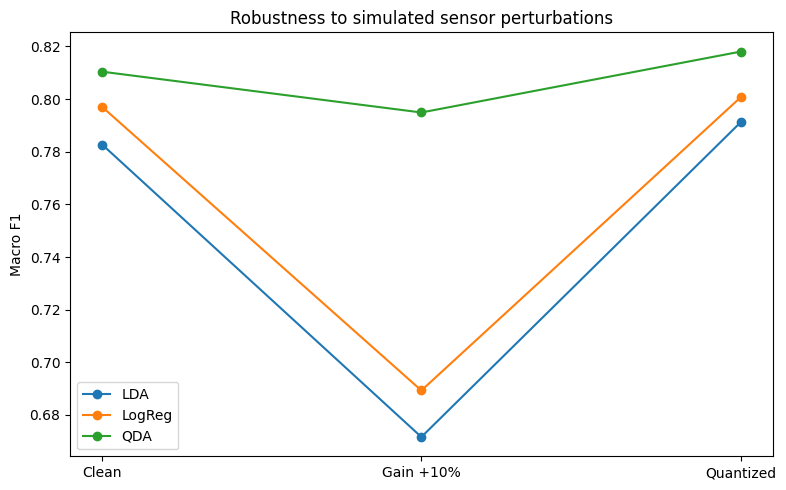

In [8]:
robust_models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    "LDA": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis(solver="lsqr", shrinkage=0.1)),
    ]),
    "QDA": Pipeline([
        ("scaler", StandardScaler()),
        ("model", QuadraticDiscriminantAnalysis(reg_param=0.2)),
    ]),
}

X_test_np = X_test.to_numpy(dtype=float)
band_indices = np.arange(0, X_test_np.shape[1], 4)
perturbed = {
    "Clean": X_test_np.copy(),
    "Gain +10%": X_test_np.copy(),
    "Quantized": X_test_np.copy(),
}
perturbed["Gain +10%"][:, band_indices] = np.clip(
    perturbed["Gain +10%"][:, band_indices] * 1.10, 0, 255
)
perturbed["Quantized"][:, band_indices] = (
    np.round(perturbed["Quantized"][:, band_indices] / 8) * 8
)

robust_rows = []
for model_name, model in robust_models.items():
    fitted = clone(model).fit(X_train, y_train)
    for perturbation, X_eval in perturbed.items():
        pred = fitted.predict(X_eval)
        robust_rows.append({
            "model": model_name,
            "perturbation": perturbation,
            "accuracy": accuracy_score(y_test, pred),
            "macro_f1": f1_score(y_test, pred, average="macro"),
        })
robustness = pd.DataFrame(robust_rows)
display(robustness)

pivot = robustness.pivot(index="perturbation", columns="model", values="macro_f1")
plt.figure(figsize=(8, 5))
for model_name in pivot.columns:
    plt.plot(pivot.index, pivot[model_name], marker="o", label=model_name)
plt.ylabel("Macro F1")
plt.title("Robustness to simulated sensor perturbations")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "sensor_robustness.png", dpi=160)
plt.show()

## Takeaways

- Strong feature correlation makes covariance assumptions important.
- Classes 1 and 7 are almost perfectly separable by logistic regression (test ROC AUC ≈ 1.0).
- Fewer features do not automatically improve held-out performance.
- Quadratic logistic regression outperforms QDA on this split, so the two approaches are not interchangeable here.
- QDA is comparatively robust to the simulated gain shift, while LDA degrades more strongly.

All model comparisons use held-out data; feature selection and threshold tuning are performed without test-set leakage.